In [1]:
import numpy as np
import pandas as pd
from pandas import Timedelta
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error 

from sklearn.preprocessing import MinMaxScaler

from google.colab import drive

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.models import load_model

from scipy import signal
%matplotlib inline

plt.style.use('Solarize_Light2')
NF_ORANGE = '#ff5a36'
NF_BLUE = '#163251'

In [2]:
!pwd
!ls -R

/content
.:
sample_data

./sample_data:
anscombe.json		      mnist_test.csv
california_housing_test.csv   mnist_train_small.csv
california_housing_train.csv  README.md


In [3]:
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Loading the raw final DataFrame
df = pd.read_csv(r'/content/drive/MyDrive/Colab Notebooks/02_4_clean_data.csv')

In [5]:
# Converting date columns to datetime and filtering for 2019-2024 period

df['date'] = pd.to_datetime(df['date'])
df['period_start_utc'] = pd.to_datetime(df['period_start_utc'])

start_date_df = '2019-01-01'
end_date_df = '2025-12-31'
df = df.query("date >= @start_date_df")
df = df.query("date <= @end_date_df")

print (df['load_forecast_da'].isna().sum())
print (df.columns)

0
Index(['date', 'year', 'month', 'day', 'dayofyear', 'hour', 'dayofweek',
       'price', 'period_start_utc', 'period_end_utc', 'load_forecast_da',
       'off_wind_da', 'on_wind_da', 'solar_da', 'gen_forecast_da',
       'res_sum_da', 'dayofyear_sin1', 'dayofyear_cos1', 'hour_sin1',
       'hour_cos1', 'dayofweek_sin1', 'dayofweek_cos1', 'is_holiday',
       'day_type', 'price_gas'],
      dtype='object')


In [6]:
# Ensure timestamp index
df.set_index('period_start_utc', inplace=True)

Text(0.5, 1.0, 'Day-Ahead Energy Prices in 2019-2025')

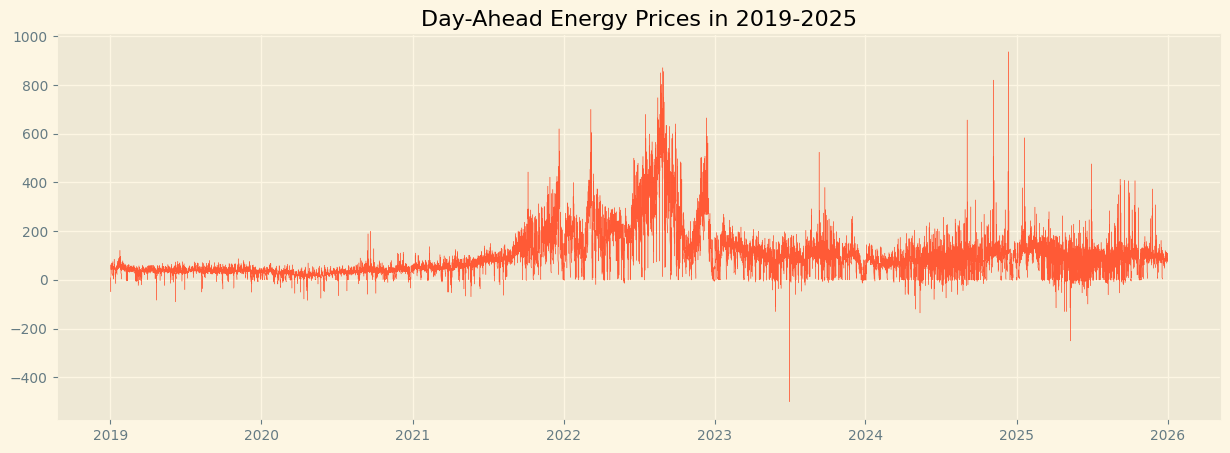

In [7]:
plt.figure(figsize=(15, 5))
plt.plot(df['date'], df['price'], label='Price', color=NF_ORANGE, linewidth=0.3)
plt.title('Day-Ahead Energy Prices in 2019-2025')

## LSTM
<p> Last layer has 1/24/168 output neurons - predicting next 1/24/168 hours at once. Using only price for predicting.
<p> Experimenting with various output layers: 1, 24, 168

In [8]:
# 2. Add residual_load = load - RES and dummies for a year

df["residual_load"] = (
    df["load_forecast_da"]
    - df["off_wind_da"]
    - df["on_wind_da"]
    - df["solar_da"]
)

df["year"] = df["date"].dt.year
df = pd.get_dummies(df, columns=["year"], drop_first=True, dtype=int)
df.columns

Index(['date', 'month', 'day', 'dayofyear', 'hour', 'dayofweek', 'price',
       'period_end_utc', 'load_forecast_da', 'off_wind_da', 'on_wind_da',
       'solar_da', 'gen_forecast_da', 'res_sum_da', 'dayofyear_sin1',
       'dayofyear_cos1', 'hour_sin1', 'hour_cos1', 'dayofweek_sin1',
       'dayofweek_cos1', 'is_holiday', 'day_type', 'price_gas',
       'residual_load', 'year_2020', 'year_2021', 'year_2022', 'year_2023',
       'year_2024', 'year_2025'],
      dtype='object')

In [9]:
# Splitting into train and test sets before normalizing

df['date'] = pd.to_datetime(df['date']).dt.tz_localize('UTC')

split_date = pd.Timestamp('2025-02-01', tz='UTC')

train_df = df[df['date'] < split_date]
test_df = df[df['date'] >= split_date]

train_df.shape, test_df.shape

((53352, 30), (8015, 30))

In [10]:
# LSTM requires normalized inputs. Scaling after the split to avoid data leakage.

price_scaler = MinMaxScaler(feature_range=(-1, 1))

scaled_train = train_df.copy()
scaled_test = test_df.copy()

scaled_train['price'] = price_scaler.fit_transform(train_df[['price']])
scaled_test['price'] = price_scaler.transform(test_df[['price']])

# Turning DataFrame into Numpy array
scaled_train = scaled_train[['price']].values
scaled_test = scaled_test[['price']].values

print (len(scaled_train), len(scaled_test))
scaled_train[:5], scaled_test[:5]

53352 8015


(array([[-0.28973459],
        [-0.30943827],
        [-0.31755647],
        [-0.31407525],
        [-0.32123263]]),
 array([[-0.12354137],
        [-0.13075445],
        [-0.13788398],
        [-0.13824602],
        [-0.13590665]]))

In [11]:
# Create sequences (lags) - in this case our lag is 1 day, i.e. 24 hours

X_train, y_train = [], []
lookback = 24

for i in range(lookback, len(scaled_train)-24):
    X_train.append(scaled_train[i-lookback:i])
    y_train.append(scaled_train[i:i+24, 0])
X_train, y_train = np.array(X_train), np.array(y_train)
print (X_train.shape, y_train.shape)

X_test, y_test = [], []

for i in range(lookback, len(scaled_test)-24):
    X_test.append(scaled_test[i-lookback:i])
    y_test.append(scaled_test[i:i+24, 0])
X_test, y_test = np.array(X_test), np.array(y_test)
print (X_test.shape, y_test.shape)

(53304, 24, 1) (53304, 24)
(7967, 24, 1) (7967, 24)


In [12]:
# Building the LSTM model

model = Sequential([
    LSTM(128, return_sequences=True, input_shape=(lookback, 1)),
    Dropout(0.2),
    LSTM(64, return_sequences=False),
    Dropout(0.2),
    Dense(24)  # predicting 24 hours (1 day) at once
])

model.compile(
    optimizer="adam",
    loss="mse"
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 24, 128)        │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 24)             │         1,560 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 117,528 (459.09 KB)

 Trainable params: 117,528 (459.09 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# Train the model
training = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 0.0081 - val_loss: 0.0054
Epoch 2/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.0037 - val_loss: 0.0052
Epoch 3/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.0032 - val_loss: 0.0051
Epoch 4/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.0032 - val_loss: 0.0053
Epoch 5/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0030 - val_loss: 0.0052
Epoch 6/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0030 - val_loss: 0.0053
Epoch 7/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.0029 - val_loss: 0.0056
Epoch 8/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.0031 - val_loss: 0.0051
Epoch 9/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 0.0029 - val_loss: 0.0053
Epoch 10/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.0030 - val_loss: 0.0054
Epoch 11/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.0029 - val_loss: 0.0054
Epoch 12/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/ste

### Loading pretrained on Google Colab model (ignore this if you trained model locally)

In [11]:
# Load the archive
with np.load(r'models\lstm_24to24_model_weights.npz') as data:
    # Reconstruct the list of weights in order
    weights_list = [data[f'arr_{i}'] for i in range(len(data.files))]

# Inject the numbers into your local model
model.set_weights(weights_list)

### Saving model

In [14]:
weights = model.get_weights()
# We use the * operator to unpack the list into the saver
np.savez('/content/drive/MyDrive/Colab Notebooks/lstm_2019_2025_24to24_1feb_weights.npz', *weights)

In [15]:
# Predict
y_pred = model.predict(X_test)

# Inverse transform to get actual price values
y_pred_inv = price_scaler.inverse_transform(y_pred)
y_test_inv = price_scaler.inverse_transform(y_test)

249/249 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [16]:
y_pred_inv.shape, y_test_inv.shape

((7967, 24), (7967, 24))

In [17]:
for h in range(24):
    rmse_h = np.sqrt(mean_squared_error(y_test_inv[:, h], y_pred_inv[:, h]))
    print(f'Hour t+{h+1:03d} -> RMSE: {rmse_h:.2f}')

Hour t+001 -> RMSE: 18.12
Hour t+002 -> RMSE: 27.93
Hour t+003 -> RMSE: 32.38
Hour t+004 -> RMSE: 34.60
Hour t+005 -> RMSE: 35.85
Hour t+006 -> RMSE: 36.99
Hour t+007 -> RMSE: 37.77
Hour t+008 -> RMSE: 38.28
Hour t+009 -> RMSE: 39.11
Hour t+010 -> RMSE: 39.53
Hour t+011 -> RMSE: 39.57
Hour t+012 -> RMSE: 39.32
Hour t+013 -> RMSE: 39.51
Hour t+014 -> RMSE: 39.71
Hour t+015 -> RMSE: 39.93
Hour t+016 -> RMSE: 40.04
Hour t+017 -> RMSE: 40.13
Hour t+018 -> RMSE: 40.71
Hour t+019 -> RMSE: 41.66
Hour t+020 -> RMSE: 42.16
Hour t+021 -> RMSE: 42.99
Hour t+022 -> RMSE: 43.46
Hour t+023 -> RMSE: 43.46
Hour t+024 -> RMSE: 42.89


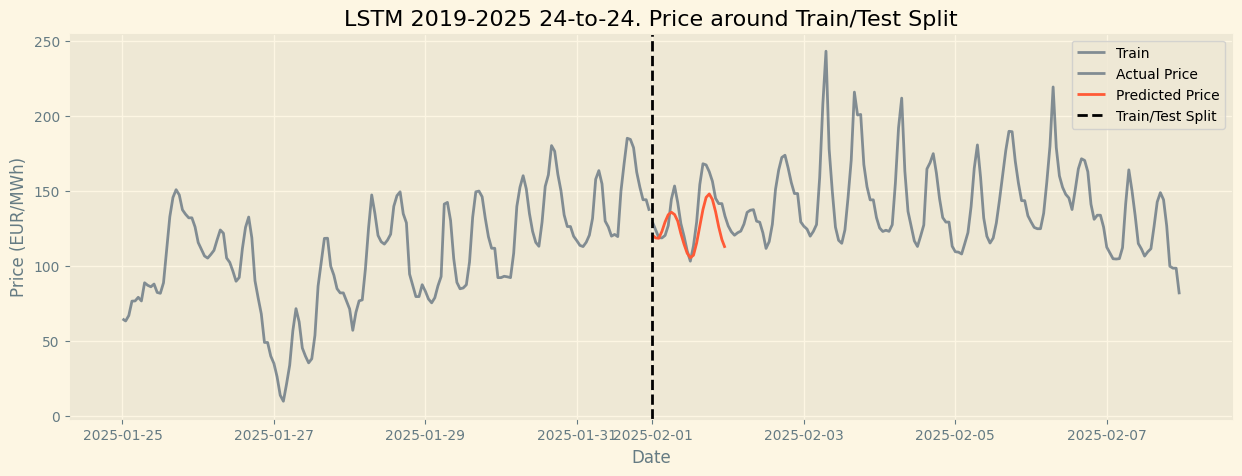

In [25]:
hours_xdays = 21 * 24

hours_xdays = pd.Timedelta(days=7)

train_portion = df.loc[(df.index >= split_date - hours_xdays) & (df.index < split_date)]
test_portion = df.loc[(df.index >= split_date) & (df.index < split_date + hours_xdays)]

# Create index for predictions (first 168 hours of test set)
pred_index = df.loc[(df.index >= split_date) & (df.index < split_date + hours_xdays)].index

# Take non-overlapping 168-hour blocks
y_pred_daily = y_pred_inv[:336:24]  # shape: (n_days, 168)
pred_values = y_pred_daily.flatten()
pred_index = test_df.index[0 : lookback + len(pred_values)]


plt.figure(figsize=(15, 5))
plt.plot(train_portion.index, train_portion['price'], label='Train', color= NF_BLUE, alpha=0.5)
plt.plot(test_portion.index, test_portion['price'], label='Actual Price', color= NF_BLUE, alpha=0.5)
plt.plot(pred_index[:24], y_pred_inv.flatten()[:24], label='Predicted Price', color=NF_ORANGE)
plt.axvline(x=split_date, color='black', linestyle='--', label='Train/Test Split')
plt.title('LSTM 2019-2025 24-to-24. Price around Train/Test Split')
plt.xlabel('Date')
plt.ylabel('Price (EUR/MWh)')
plt.legend()
plt.grid(True)
plt.show()

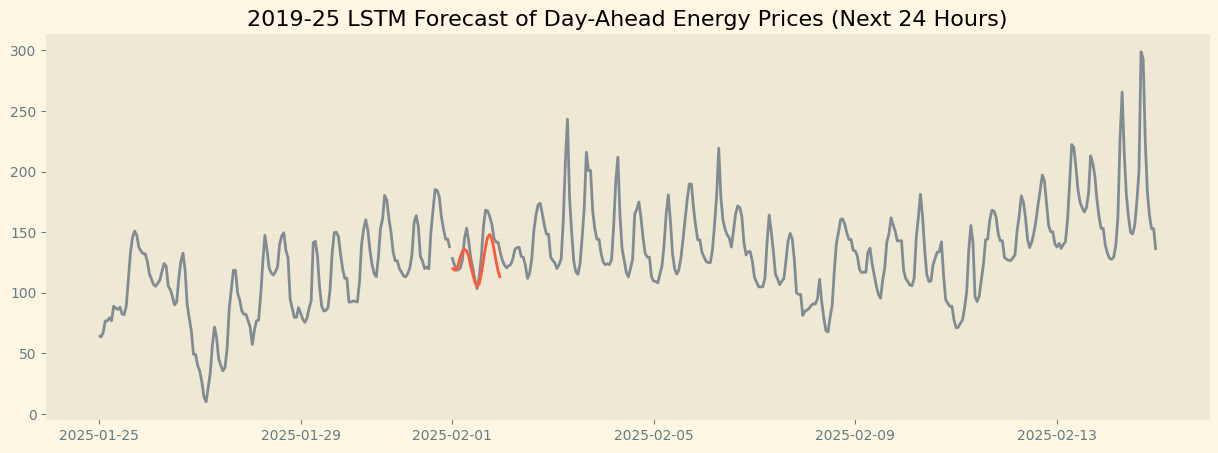

In [29]:
# 1. Define the ranges to match the graph
history_range = pd.Timedelta(days=7)
future_range = pd.Timedelta(days=14) # Graph shows roughly 2 weeks of test data

# 2. Slice the data
train_portion = df.loc[(df.index >= split_date - history_range) & (df.index < split_date)]
test_portion = df.loc[(df.index >= split_date) & (df.index < split_date + future_range)]

# 3. Prepare prediction data (First 24 hours)
# Assuming y_pred_inv contains your hourly predictions starting at split_date
n_steps = 24
y_pred_plot = y_pred_inv.flatten()[:n_steps]
pred_index = df.loc[split_date : ].index[:n_steps]

# 4. Plotting
plt.figure(figsize=(15, 5))

# Plot Historical (Lower alpha, matches NF_BLUE)
plt.plot(train_portion.index, train_portion['price'], label='Historical', color=NF_BLUE, alpha=0.5)

# Plot Actual Test (Continuing the line)
plt.plot(test_portion.index, test_portion['price'], label='Actual', color=NF_BLUE, alpha=0.5)

# Plot Prediction (Specific 24-hour window)
plt.plot(pred_index, y_pred_plot, label='Predicted', color=NF_ORANGE, linewidth=2)

# Optional: Add the confidence interval shading if you have it for LSTM 
# (Note: LSTMs don't provide this by default like SARIMAX does)

plt.title('2019-25 LSTM Forecast of Day-Ahead Energy Prices (Next 24 Hours)')
plt.grid(True, alpha=0.3)
plt.show()

In [27]:
test_portion.head()

,date,month,day,dayofyear,hour,dayofweek,price,period_end_utc,load_forecast_da,off_wind_da,...,is_holiday,day_type,price_gas,residual_load,year_2020,year_2021,year_2022,year_2023,year_2024,year_2025
period_start_utc,,,,,,,,,,,,,,,,,,,,,
2025-02-01 00:00:00+00:00,2025-02-01 00:00:00+00:00,2,1,32,0,5,129.42,2025-02-01 01:00:00+00:00,47770.4800,502.1050,...,0,weekend,53.237,42112.2800,0,0,0,0,0,1
2025-02-01 01:00:00+00:00,2025-02-01 00:00:00+00:00,2,1,32,1,5,124.24,2025-02-01 02:00:00+00:00,46513.0225,524.8025,...,0,weekend,53.237,41099.9950,0,0,0,0,0,1
2025-02-01 02:00:00+00:00,2025-02-01 00:00:00+00:00,2,1,32,2,5,119.12,2025-02-01 03:00:00+00:00,45863.2050,568.4375,...,0,weekend,53.237,40667.2975,0,0,0,0,0,1
2025-02-01 03:00:00+00:00,2025-02-01 00:00:00+00:00,2,1,32,3,5,118.86,2025-02-01 04:00:00+00:00,46343.3425,578.1300,...,0,weekend,53.237,41346.4750,0,0,0,0,0,1
2025-02-01 04:00:00+00:00,2025-02-01 00:00:00+00:00,2,1,32,4,5,120.54,2025-02-01 05:00:00+00:00,46981.5250,548.9000,...,0,weekend,53.237,42113.4050,0,0,0,0,0,1


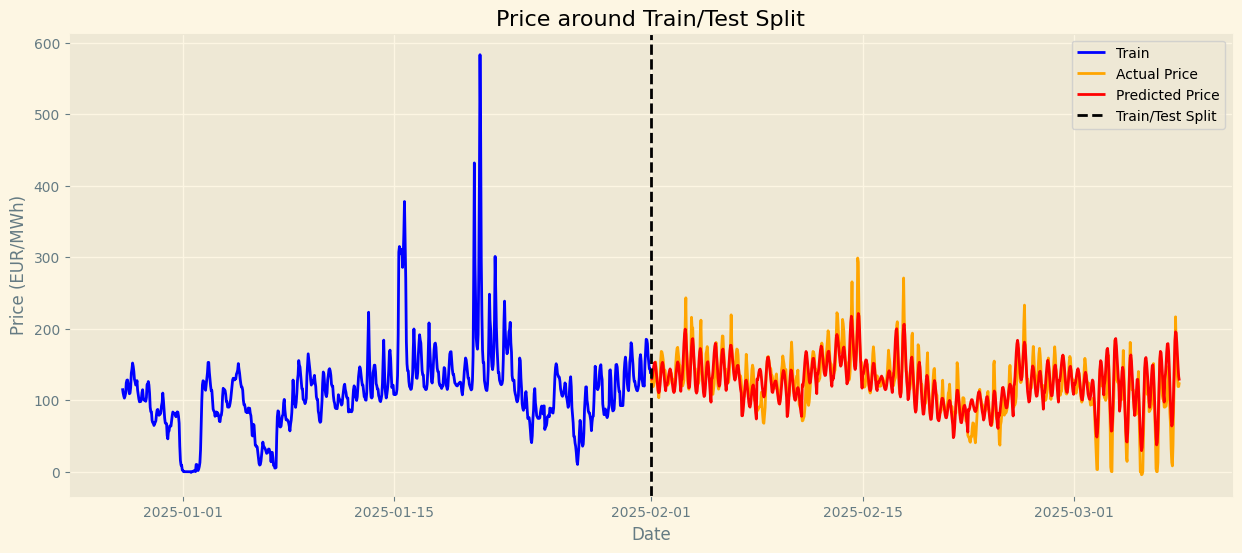

In [20]:
hours_xdays = 14 * 24

hours_xdays = pd.Timedelta(days=35)

train_portion = df.loc[(df.index >= split_date - hours_xdays) & (df.index < split_date)]
test_portion = df.loc[(df.index >= split_date) & (df.index < split_date + hours_xdays)]

# Create index for predictions (first 168 hours of test set)
#pred_index = df.loc[(df.index >= split_date) & (df.index < split_date + hours_xdays)].index

# Take non-overlapping 168-hour blocks
y_pred_daily = y_pred_inv[::24]  # shape: (n_days, 168)
pred_values = y_pred_daily.flatten()
pred_index = test_df.index[0 : lookback + len(pred_values)]

plt.figure(figsize=(15, 6))
plt.plot(train_portion.index, train_portion['price'], label='Train', color='blue')
plt.plot(test_portion.index, test_portion['price'], label='Actual Price', color='orange')
plt.plot(pred_index[0:840], pred_values[0:840], label='Predicted Price', color='red')
plt.axvline(x=split_date, color='black', linestyle='--', label='Train/Test Split')
plt.title('Price around Train/Test Split')
plt.xlabel('Date')
plt.ylabel('Price (EUR/MWh)')
plt.legend()
plt.grid(True)
plt.show()

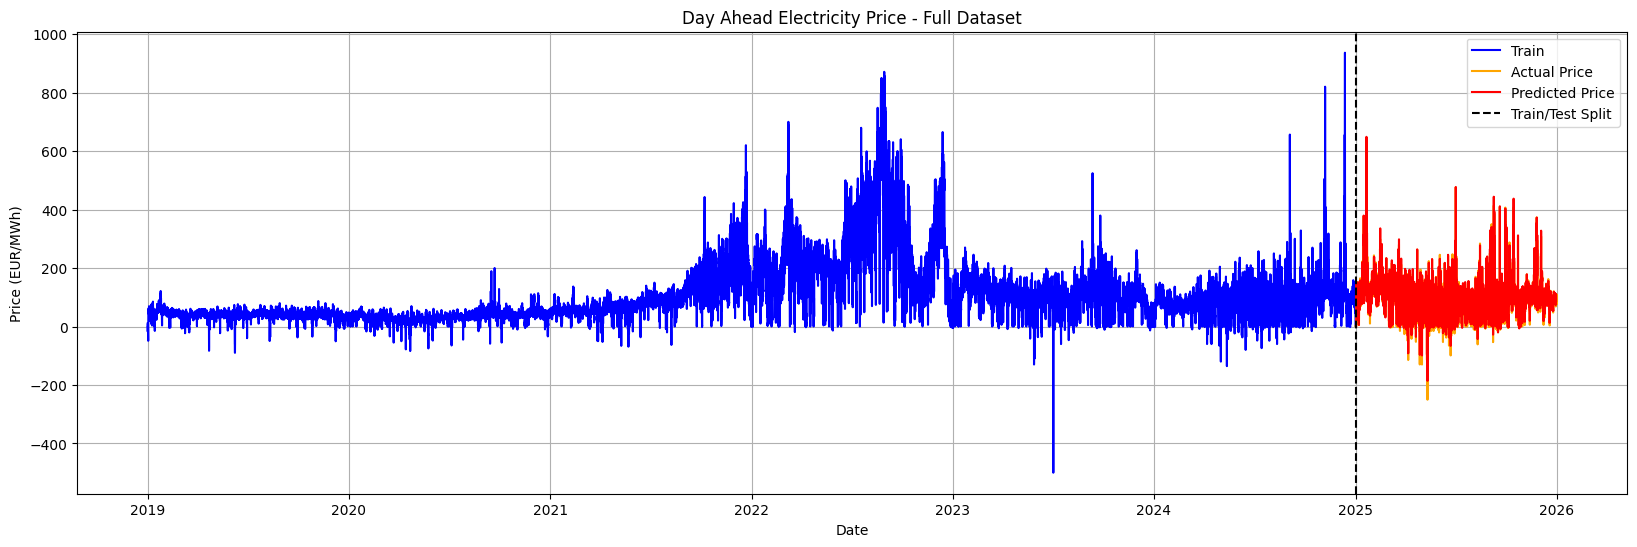

In [29]:
# Full prediction index covering entire test set
y_pred_t1 = y_pred_inv[:, 0]  # only t+1 from each sample
pred_index = test_df.index[lookback : lookback + len(y_pred_t1)]

plt.figure(figsize=(20, 6))
plt.plot(train_df.index, train_df['price'], label='Train', color='blue')
plt.plot(test_df.index, test_df['price'], label='Actual Price', color='orange')
plt.plot(pred_index, y_pred_t1, label='Predicted Price', color='red')
plt.axvline(x=split_date, color='black', linestyle='--', label='Train/Test Split')
plt.title('Day Ahead Electricity Price - Full Dataset')
plt.xlabel('Date')
plt.ylabel('Price (EUR/MWh)')
plt.legend()
plt.grid(True)
plt.show()

In [30]:
# Assessing RMSE and MAE

rmse = np.sqrt(mean_squared_error(y_test_inv.flatten(), y_pred_inv.flatten()))
mae = mean_absolute_error(y_test_inv.flatten(), y_pred_inv.flatten())

print(f'RMSE: {rmse:.2f} EUR/MWh')
print(f'MAE: {mae:.2f} EUR/MWh')

RMSE: 38.56 EUR/MWh
MAE: 26.44 EUR/MWh


In [31]:
# 1. Create a DataFrame from your arrays
export_df = pd.DataFrame({
    'time_stamp': pred_index,
    'pred_price': y_pred_plot
})

# 2. Export to CSV
# index=False prevents pandas from adding an extra 'unnamed' column for the row numbers
export_df.to_csv('/content/drive/MyDrive/Colab Notebooks/lstm_2019_2025_predictions.csv', index=False)